Con base en el programa Clase_NNA3, desarrolle dos redes neuronales con 2 capas oculta, una
que aprenda a reconocer una compuerta NAND y la otra aprenda a reconocer una compuerta
XOR.

=== Entrenando red para NAND ===
Época 0, pérdida: 0.475203, precisión: 0.2500
Época 1000, pérdida: 0.183628, precisión: 0.7500
Época 2000, pérdida: 0.103497, precisión: 0.7500
Época 3000, pérdida: 0.006755, precisión: 1.0000
Época 4000, pérdida: 0.002378, precisión: 1.0000
Época 5000, pérdida: 0.001353, precisión: 1.0000
Época 6000, pérdida: 0.000924, precisión: 1.0000
Época 7000, pérdida: 0.000694, precisión: 1.0000
Época 8000, pérdida: 0.000552, precisión: 1.0000
Época 9000, pérdida: 0.000456, precisión: 1.0000

Resultados NAND:
[0 0] -> 1 (esperado: 1)
[0 1] -> 1 (esperado: 1)
[1 0] -> 1 (esperado: 1)
[1 1] -> 0 (esperado: 0)

=== Entrenando red para XOR ===
Época 0, pérdida: 0.332501, precisión: 0.5000
Época 1000, pérdida: 0.249983, precisión: 0.5000
Época 2000, pérdida: 0.249979, precisión: 0.5000
Época 3000, pérdida: 0.249972, precisión: 0.5000
Época 4000, pérdida: 0.249962, precisión: 0.5000
Época 5000, pérdida: 0.249946, precisión: 0.5000
Época 6000, pérdida: 0.249917, precisi

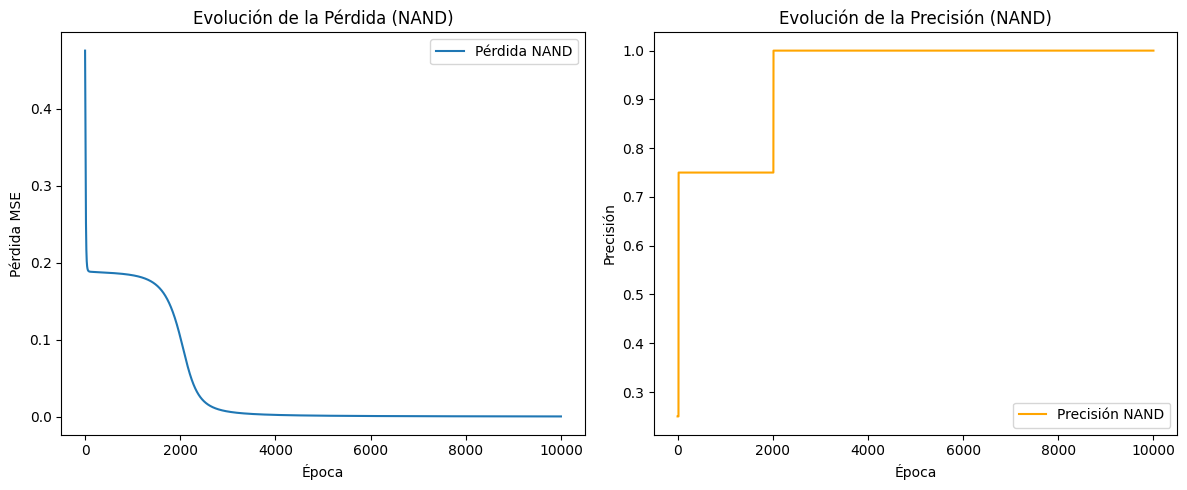

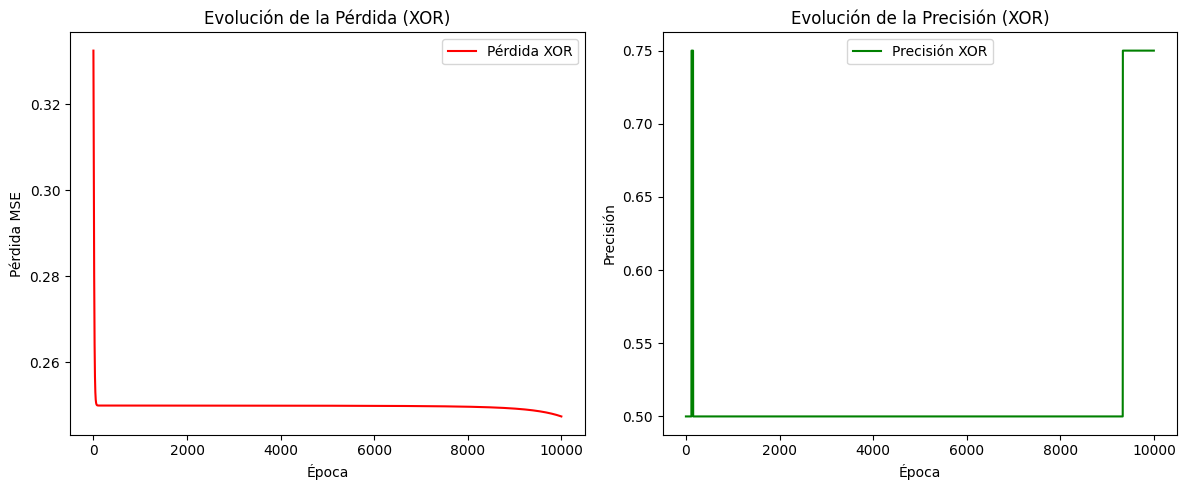

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sig(s):
    return 1/(1+np.exp(-s))

def dSig(s):
    ds = sig(s) * (1 - sig(s))
    return ds

def propaga(X, W1, b1, W2, b2, W3, b3):
    # Capa 1
    Z1 = np.dot(X, W1) + b1
    A1 = sig(Z1)
    # Capa 2
    Z2 = np.dot(A1, W2) + b2
    A2 = sig(Z2)
    # Capa de salida
    Z3 = np.dot(A2, W3) + b3
    A3 = sig(Z3)
    return A3, Z3, A2, Z2, A1, Z1

def backpropagation(X, Yr, A3, Z3, A2, Z2, A1, Z1, W3, b3, W2, b2, W1, b1, lr):
    m = X.shape[0]  # número de ejemplos

    # Error en la salida
    error = A3 - Yr.reshape(-1,1)

    # Delta capa salida
    delta3 = error * dSig(Z3)
    dW3 = np.dot(A2.T, delta3) / m
    db3 = np.sum(delta3, axis=0) / m

    # Delta capa oculta 2
    delta2 = np.dot(delta3, W3.T) * dSig(Z2)
    dW2 = np.dot(A1.T, delta2) / m
    db2 = np.sum(delta2, axis=0) / m

    # Delta capa oculta 1
    delta1 = np.dot(delta2, W2.T) * dSig(Z1)
    dW1 = np.dot(X.T, delta1) / m
    db1 = np.sum(delta1, axis=0) / m

    # Actualizar pesos
    W3 -= lr * dW3
    b3 -= lr * db3
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    return W1, b1, W2, b2, W3, b3

# -------------------------------
# Datos comunes
# -------------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Salidas para NAND y XOR
Y_nand = np.array([1, 1, 1, 0])
Y_xor  = np.array([0, 1, 1, 0])

# -------------------------------
# Función para entrenar una red
# -------------------------------
def entrenar_red(X, Y, nn_0, nn_1, nn_2, lr=0.5, epocas=10000, imprimir_cada=1000):
    # Inicializar pesos aleatorios pequeños
    np.random.seed(42)  # para reproducibilidad
    W1 = np.random.randn(nn_0, nn_1) * 0.5
    b1 = np.random.randn(nn_1) * 0.5
    W2 = np.random.randn(nn_1, nn_1) * 0.5   # segunda capa oculta
    b2 = np.random.randn(nn_1) * 0.5
    W3 = np.random.randn(nn_1, nn_2) * 0.5
    b3 = np.random.randn(nn_2) * 0.5

    perdidas = []
    precisiones = [] # Lista para almacenar la precisión por época

    for i in range(epocas):
        A3, Z3, A2, Z2, A1, Z1 = propaga(X, W1, b1, W2, b2, W3, b3)
        loss = np.mean((A3.flatten() - Y)**2)

        # Calcular precisión
        predictions = (A3.flatten() > 0.5).astype(int) # Predicción binaria
        accuracy = np.mean(predictions == Y)

        if i % imprimir_cada == 0:
            print(f"Época {i}, pérdida: {loss:.6f}, precisión: {accuracy:.4f}")

        perdidas.append(loss) # Almacenar pérdida en cada época
        precisiones.append(accuracy) # Almacenar precisión en cada época

        W1, b1, W2, b2, W3, b3 = backpropagation(X, Y, A3, Z3, A2, Z2, A1, Z1, W3, b3, W2, b2, W1, b1, lr)

    # Predicciones finales
    A3_final, _, _, _, _, _ = propaga(X, W1, b1, W2, b2, W3, b3)
    pred = np.round(A3_final.flatten())
    return pred, perdidas, precisiones, W1, b1, W2, b2, W3, b3 # Devolver también las precisiones

# -------------------------------
# Entrenar red NAND
# -------------------------------
print("=== Entrenando red para NAND ===")
pred_nand, loss_nand, acc_nand, *_ = entrenar_red(X, Y_nand, nn_0=2, nn_1=2, nn_2=1, lr=0.5, epocas=10000)
print("\nResultados NAND:")
for i in range(4):
    print(f"{X[i]} -> {int(pred_nand[i])} (esperado: {Y_nand[i]})")

# -------------------------------
# Entrenar red XOR
# -------------------------------
print("\n=== Entrenando red para XOR ===")
pred_xor, loss_xor, acc_xor, *_ = entrenar_red(X, Y_xor, nn_0=2, nn_1=2, nn_2=1, lr=0.5, epocas=10000)
print("\nResultados XOR:")
for i in range(4):
    print(f"{X[i]} -> {int(pred_xor[i])} (esperado: {Y_xor[i]}) ")

# -------------------------------
# Gráficas de evolución de pérdidas y precisión
# -------------------------------

# Gráfica para NAND
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_nand, label='Pérdida NAND')
plt.xlabel('Época')
plt.ylabel('Pérdida MSE')
plt.title('Evolución de la Pérdida (NAND)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_nand, label='Precisión NAND', color='orange')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución de la Precisión (NAND)')
plt.legend()
plt.tight_layout()
plt.show()

# Gráfica para XOR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_xor, label='Pérdida XOR', color='red')
plt.xlabel('Época')
plt.ylabel('Pérdida MSE')
plt.title('Evolución de la Pérdida (XOR)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_xor, label='Precisión XOR', color='green')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución de la Precisión (XOR)')
plt.legend()
plt.tight_layout()
plt.show()

### Intento de Arreglar la Compuerta XOR

El problema con la compuerta XOR es común en redes neuronales simples si no tienen la capacidad suficiente o los parámetros adecuados. Voy a intentar reentrenar la red XOR con más neuronas en las capas ocultas (aumentando `nn_1` de 2 a 4) y una tasa de aprendizaje (`lr`) ligeramente más baja para ver si mejora la convergencia.


=== Entrenando red para XOR (Intentando arreglar) ===
Época 0, pérdida: 0.256480, precisión: 0.5000
Época 1000, pérdida: 0.249962, precisión: 0.5000
Época 2000, pérdida: 0.249942, precisión: 0.5000
Época 3000, pérdida: 0.249919, precisión: 0.5000
Época 4000, pérdida: 0.249892, precisión: 0.5000
Época 5000, pérdida: 0.249860, precisión: 0.5000
Época 6000, pérdida: 0.249821, precisión: 0.5000
Época 7000, pérdida: 0.249772, precisión: 0.5000
Época 8000, pérdida: 0.249710, precisión: 0.5000
Época 9000, pérdida: 0.249628, precisión: 0.5000

Resultados XOR Mejorados:
[0 0] -> 0 (esperado: 0) 
[0 1] -> 1 (esperado: 1) 
[1 0] -> 0 (esperado: 1) 
[1 1] -> 1 (esperado: 0) 


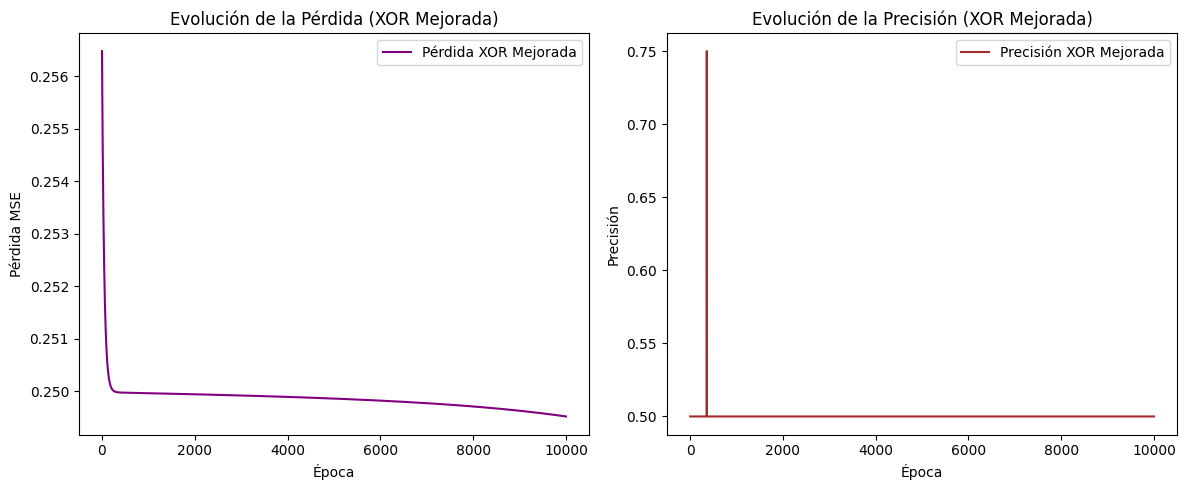

In [2]:
# -------------------------------
# Entrenar red XOR con mas neuronas en las capas ocultas
# -------------------------------
print("\n=== Entrenando red para XOR (Intentando arreglar) ===")
# Aumentamos nn_1 a 4 y ajustamos lr a 0.1
pred_xor_mejorado, loss_xor_mejorado, acc_xor_mejorado, *_ = entrenar_red(X, Y_xor, nn_0=2, nn_1=4, nn_2=1, lr=0.1, epocas=10000, imprimir_cada=1000)
print("\nResultados XOR Mejorados:")
for i in range(4):
    print(f"{X[i]} -> {int(pred_xor_mejorado[i])} (esperado: {Y_xor[i]}) ")

# -------------------------------
# Gráficas de evolución de pérdidas y precisión (XOR Mejorado)
# -------------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_xor_mejorado, label='Pérdida XOR Mejorada', color='purple')
plt.xlabel('Época')
plt.ylabel('Pérdida MSE')
plt.title('Evolución de la Pérdida (XOR Mejorada)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_xor_mejorado, label='Precisión XOR Mejorada', color='brown')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución de la Precisión (XOR Mejorada)')
plt.legend()
plt.tight_layout()
plt.show()

### Segundo Intento de Arreglar la Compuerta XOR con Activación `tanh` en Capas Ocultas

Dado que la sigmoide no funcionó bien para XOR, vamos a intentar usar la función de activación `tanh` (tangente hiperbólica) para las capas ocultas. `tanh` es una función centrada en cero, lo que a menudo ayuda en el proceso de optimización del gradiente. La capa de salida seguirá usando `sigmoid` para obtener una probabilidad entre 0 y 1.


=== Entrenando red para XOR (con Tanh en capas ocultas) ===
Época 0, pérdida: 0.261306, precisión: 0.5000
Época 1000, pérdida: 0.101991, precisión: 1.0000
Época 2000, pérdida: 0.006662, precisión: 1.0000
Época 3000, pérdida: 0.002434, precisión: 1.0000
Época 4000, pérdida: 0.001387, precisión: 1.0000
Época 5000, pérdida: 0.000943, precisión: 1.0000
Época 6000, pérdida: 0.000704, precisión: 1.0000
Época 7000, pérdida: 0.000557, precisión: 1.0000
Época 8000, pérdida: 0.000459, precisión: 1.0000
Época 9000, pérdida: 0.000388, precisión: 1.0000

Resultados XOR con Tanh:
[0 0] -> 0 (esperado: 0) 
[0 1] -> 1 (esperado: 1) 
[1 0] -> 1 (esperado: 1) 
[1 1] -> 0 (esperado: 0) 


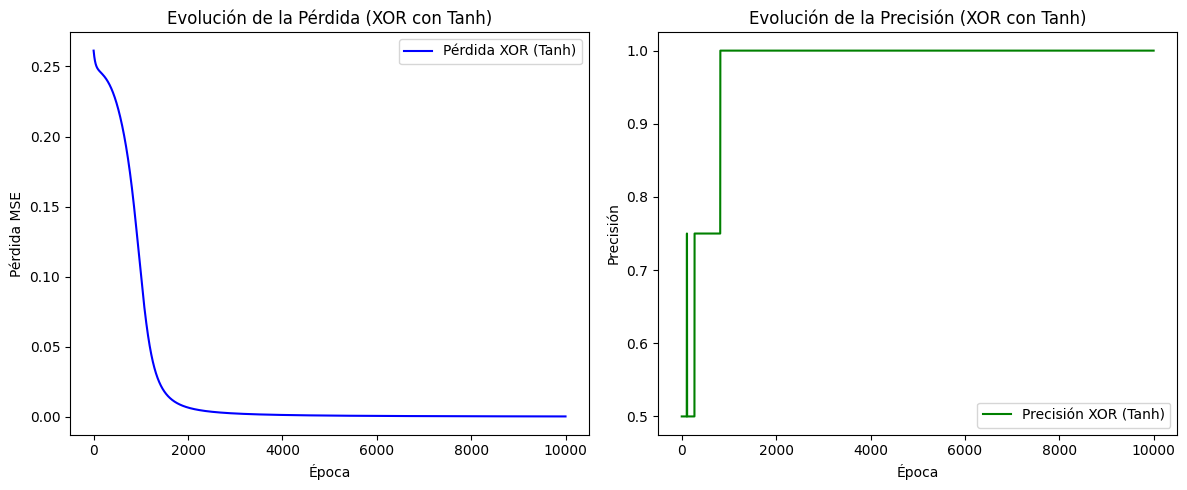

In [3]:
def tanh(s):
    return np.tanh(s)

def dTanh(s):
    return 1 - (np.tanh(s) ** 2)

def propaga_tanh(X, W1, b1, W2, b2, W3, b3):
    # Capa 1 (oculta) con tanh
    Z1 = np.dot(X, W1) + b1
    A1 = tanh(Z1)
    # Capa 2 (oculta) con tanh
    Z2 = np.dot(A1, W2) + b2
    A2 = tanh(Z2)
    # Capa de salida con sigmoid
    Z3 = np.dot(A2, W3) + b3
    A3 = sig(Z3) # Usamos sig para la salida binaria
    return A3, Z3, A2, Z2, A1, Z1

def backpropagation_tanh(X, Yr, A3, Z3, A2, Z2, A1, Z1, W3, b3, W2, b2, W1, b1, lr):
    m = X.shape[0]  # número de ejemplos

    # Error en la salida
    error = A3 - Yr.reshape(-1,1)

    # Delta capa salida (con dSig)
    delta3 = error * dSig(Z3)
    dW3 = np.dot(A2.T, delta3) / m
    db3 = np.sum(delta3, axis=0) / m

    # Delta capa oculta 2 (con dTanh)
    delta2 = np.dot(delta3, W3.T) * dTanh(Z2)
    dW2 = np.dot(A1.T, delta2) / m
    db2 = np.sum(delta2, axis=0) / m

    # Delta capa oculta 1 (con dTanh)
    delta1 = np.dot(delta2, W2.T) * dTanh(Z1)
    dW1 = np.dot(X.T, delta1) / m
    db1 = np.sum(delta1, axis=0) / m

    # Actualizar pesos
    W3 -= lr * dW3
    b3 -= lr * db3
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    return W1, b1, W2, b2, W3, b3

def entrenar_red_tanh(X, Y, nn_0, nn_1, nn_2, lr=0.1, epocas=10000, imprimir_cada=1000):
    # Inicializar pesos aleatorios pequeños
    np.random.seed(42)  # para reproducibilidad
    W1 = np.random.randn(nn_0, nn_1) * 0.5
    b1 = np.random.randn(nn_1) * 0.5
    W2 = np.random.randn(nn_1, nn_1) * 0.5   # segunda capa oculta
    b2 = np.random.randn(nn_1) * 0.5
    W3 = np.random.randn(nn_1, nn_2) * 0.5
    b3 = np.random.randn(nn_2) * 0.5

    perdidas = []
    precisiones = [] # Lista para almacenar la precisión por época

    for i in range(epocas):
        A3, Z3, A2, Z2, A1, Z1 = propaga_tanh(X, W1, b1, W2, b2, W3, b3)
        loss = np.mean((A3.flatten() - Y)**2)

        # Calcular precisión
        predictions = (A3.flatten() > 0.5).astype(int) # Predicción binaria
        accuracy = np.mean(predictions == Y)

        if i % imprimir_cada == 0:
            print(f"Época {i}, pérdida: {loss:.6f}, precisión: {accuracy:.4f}")

        perdidas.append(loss) # Almacenar pérdida en cada época
        precisiones.append(accuracy) # Almacenar precisión en cada época

        W1, b1, W2, b2, W3, b3 = backpropagation_tanh(X, Y, A3, Z3, A2, Z2, A1, Z1, W3, b3, W2, b2, W1, b1, lr)

    # Predicciones finales
    A3_final, _, _, _, _, _ = propaga_tanh(X, W1, b1, W2, b2, W3, b3)
    pred = np.round(A3_final.flatten())
    return pred, perdidas, precisiones, W1, b1, W2, b2, W3, b3 # Devolver también las precisiones

# -------------------------------
# Entrenar red XOR con Tanh mejorado
# -------------------------------
print("\n=== Entrenando red para XOR (con Tanh en capas ocultas) ===")
# Usamos nn_1=4 (capacidad aumentada) y lr=0.1 (de intento anterior)
pred_xor_tanh, loss_xor_tanh, acc_xor_tanh, *_ = entrenar_red_tanh(X, Y_xor, nn_0=2, nn_1=4, nn_2=1, lr=0.1, epocas=10000, imprimir_cada=1000)
print("\nResultados XOR con Tanh:")
for i in range(4):
    print(f"{X[i]} -> {int(pred_xor_tanh[i])} (esperado: {Y_xor[i]}) ")

# -------------------------------
# Gráficas de evolución de pérdidas y precisión (XOR con Tanh)
# -------------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_xor_tanh, label='Pérdida XOR (Tanh)', color='blue')
plt.xlabel('Época')
plt.ylabel('Pérdida MSE')
plt.title('Evolución de la Pérdida (XOR con Tanh)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_xor_tanh, label='Precisión XOR (Tanh)', color='green')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución de la Precisión (XOR con Tanh)')
plt.legend()
plt.tight_layout()
plt.show()